# 1. Importation des bibliothèques

On utilise :

- `numpy` pour le calcul numérique ;
- `pandas` pour manipuler les données ;
- `matplotlib` pour les graphiques ;
- `scikit-learn` pour les modèles d'apprentissage statistique.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

plt.style.use('ggplot')
warnings.filterwarnings('ignore')

# 2. Rappel théorique : modèle de régression linéaire

On considère un échantillon de données :

$$
(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)
$$

où :

- $x_i$ représente les variables explicatives ;
- $y_i$ représente la variable à prédire.

Dans le cas général, le modèle de régression linéaire multiple s'écrit :

$$
Y = X\beta + \varepsilon
$$

avec :

- $Y$ : vecteur des valeurs observées ;
- $X$ : matrice des variables explicatives ;
- $\beta$ : vecteur des coefficients inconnus ;
- $\varepsilon$ : terme d'erreur.

L'objectif est d'estimer $\beta$, puis d'utiliser le modèle pour prédire de nouvelles valeurs.

# 3. Méthode des moindres carrés

La méthode des moindres carrés cherche à minimiser la somme des carrés des erreurs :

$$
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

où :

- $y_i$ est la vraie valeur observée ;
- $\hat{y}_i$ est la valeur prédite par le modèle.

Lorsque la matrice $X^TX$ est inversible, l'estimateur des moindres carrés est :

$$
\hat{\beta} = (X^TX)^{-1}X^TY
$$

En pratique, on utilise ici `LinearRegression` de `scikit-learn`.

# 4. Apprentissage statistique

Dans un problème d'apprentissage supervisé, on dispose :

- de variables explicatives $X$ ;
- d'une variable cible $Y$ ;
- d'un modèle qui apprend une relation entre $X$ et $Y$.

On sépare généralement les données en deux parties :

- **ensemble d'apprentissage** : utilisé pour ajuster le modèle ;
- **ensemble de test** : utilisé pour évaluer la qualité de prédiction sur des données non vues.

L'objectif n'est pas seulement de bien expliquer les données utilisées pour entraîner le modèle, mais surtout de bien prédire de nouvelles observations.

# 5. Chargement du jeu de données

On utilise le jeu de données `50_Startups`.

Chaque ligne représente une startup. Les variables sont :

- `R&D Spend` : dépenses en recherche et développement ;
- `Administration` : dépenses administratives ;
- `Marketing Spend` : dépenses marketing ;
- `State` : État américain où se trouve la startup ;
- `Profit` : profit réalisé.

La variable cible est :

$$
Y = \text{Profit}
$$

Les variables explicatives sont les autres colonnes.

In [2]:
dataset = pd.read_csv('50_Startups.csv')
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


# 6. Prétraitement et analyse exploratoire des données

In [3]:
dataset.shape

(50, 5)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
dataset.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [6]:
dataset.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

# 7. Étude des distributions

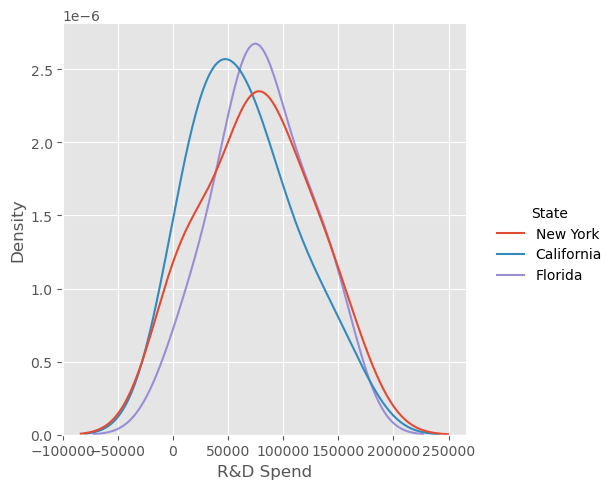

In [7]:
sns.displot(data=dataset, x='R&D Spend', hue='State', kind='kde') 
#hue kima group by w kind hia forme de la courbe


$$skew := \dfrac{1}{N}\dfrac{\sum_{i=1}^{N} \left(x_i-\bar{x}\right)^3}{std^3},\quad kurt:= \dfrac{1}{N}\dfrac{\sum_{i=1}^{N} \left(x_i-\bar{x}\right)^4}{std^4}$$

http://www.normalesup.org/~carpenti/Notes/Skewness-Kurtosis/caract-forme.html

In [8]:
from scipy.stats import kurtosis, skew
print("skew : ",skew(dataset['R&D Spend']))
print("kurt : ",kurtosis(dataset['R&D Spend']))

skew :  0.15904052321503395
kurt :  -0.8050676431519039


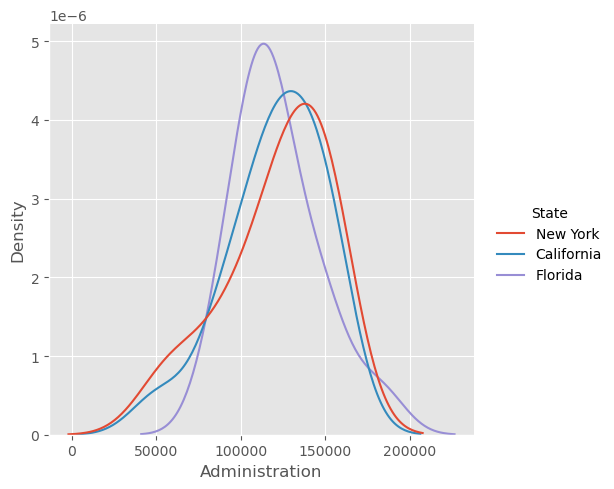

In [9]:
sns.displot(data=dataset, x='Administration', hue='State', kind='kde')

In [10]:
print("skew : ",skew(dataset['Administration']))
print("kurt : ",kurtosis(dataset['Administration']))

skew :  -0.4742300698920047
kurt :  0.08553840791984113


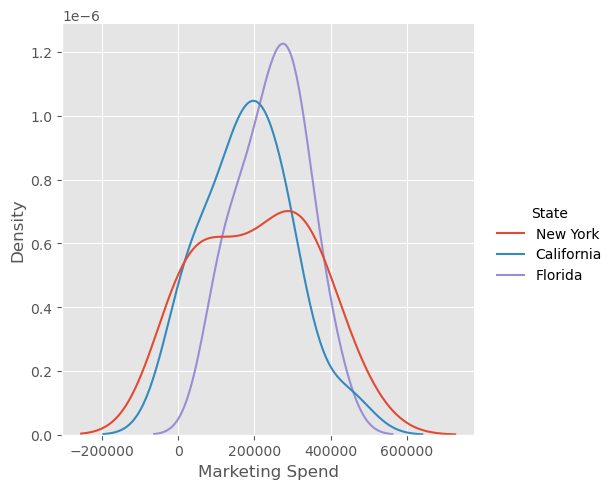

In [11]:
sns.displot(data=dataset, x='Marketing Spend', hue='State', kind='kde')

In [12]:
print("skew : ",skew(dataset['Marketing Spend']))
print("kurt : ",kurtosis(dataset['Marketing Spend']))

skew :  -0.04506631617666136
kurt :  -0.7240327111087308


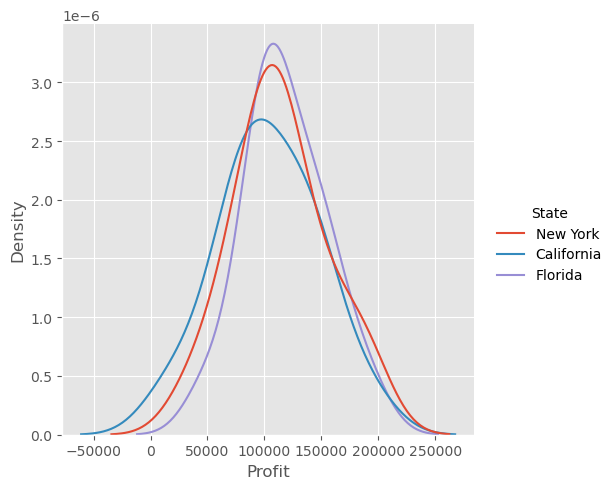

In [13]:
sns.displot(data=dataset, x='Profit', hue='State', kind='kde')

In [14]:
print("skew : ",skew(dataset['Profit']))
print("kurt : ",kurtosis(dataset['Profit']))

skew :  0.02258638356958943
kurt :  -0.17529637679752152


# 8. Statistiques descriptives complémentaires

In [15]:
dataset.describe(include=['object'])

,State
count,50
unique,3
top,New York
freq,17


In [16]:
dataset.loc[dataset['R&D Spend'] == 0.0] #.loc Access group of values using labels.

,R&D Spend,Administration,Marketing Spend,State,Profit
47,0.0,135426.92,0.00,California,42559.73
49,0.0,116983.80,45173.06,California,14681.40


Recall some basics statistical functions
$$mean:=m=\frac{1}{n}\sum_{i=1}^nx_i,\;variance:=var=\frac{1}{n}\sum_{i=1}^n\left(x_i-m\right)^2,\;ecart\_type:=std=\sqrt{var}$$

In [17]:
#extraire les observations qui on depensé plus que la moyenne en marketing spend et qui sont basées sur New York
condition1=dataset['State'] == 'New York'
condition1
condition2=dataset['Marketing Spend']> dataset['Marketing Spend'].mean()
dataset.loc[condition1 & condition2]

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
3,144372.41,118671.85,383199.62,New York,182901.99
5,131876.90,99814.71,362861.36,New York,156991.12
8,120542.52,148718.95,311613.29,New York,152211.77
15,114523.61,122616.84,261776.23,New York,129917.04
17,94657.16,145077.58,282574.31,New York,125370.37
21,78389.47,153773.43,299737.29,New York,111313.02
27,72107.60,127864.55,353183.81,New York,105008.31


# 9. Analyse de la variable qualitative `State`

In [18]:
dataset.describe(include='object')

,State
count,50
unique,3
top,New York
freq,17


In [19]:
dataset.State.value_counts() #frequency mtaa kol modality

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

In [20]:
sns.set(style="whitegrid")

# 10. Valeurs atypiques et boxplots

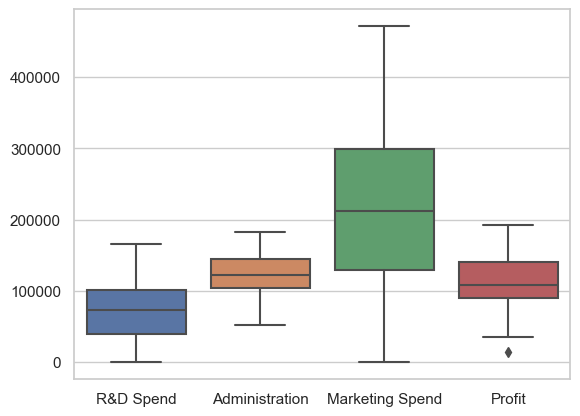

In [21]:
ax = sns.boxplot(data=dataset, orient="v") #orient=v maaneha verticale

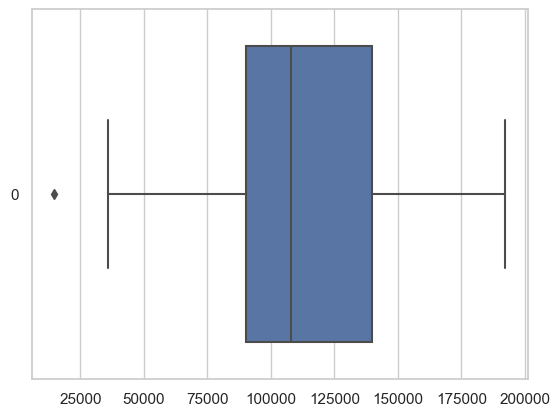

In [22]:
ax = sns.boxplot(data = dataset['Profit'], orient = 'h')

In [23]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [24]:
sns.set(style="ticks")

# 11. Analyse bivariée

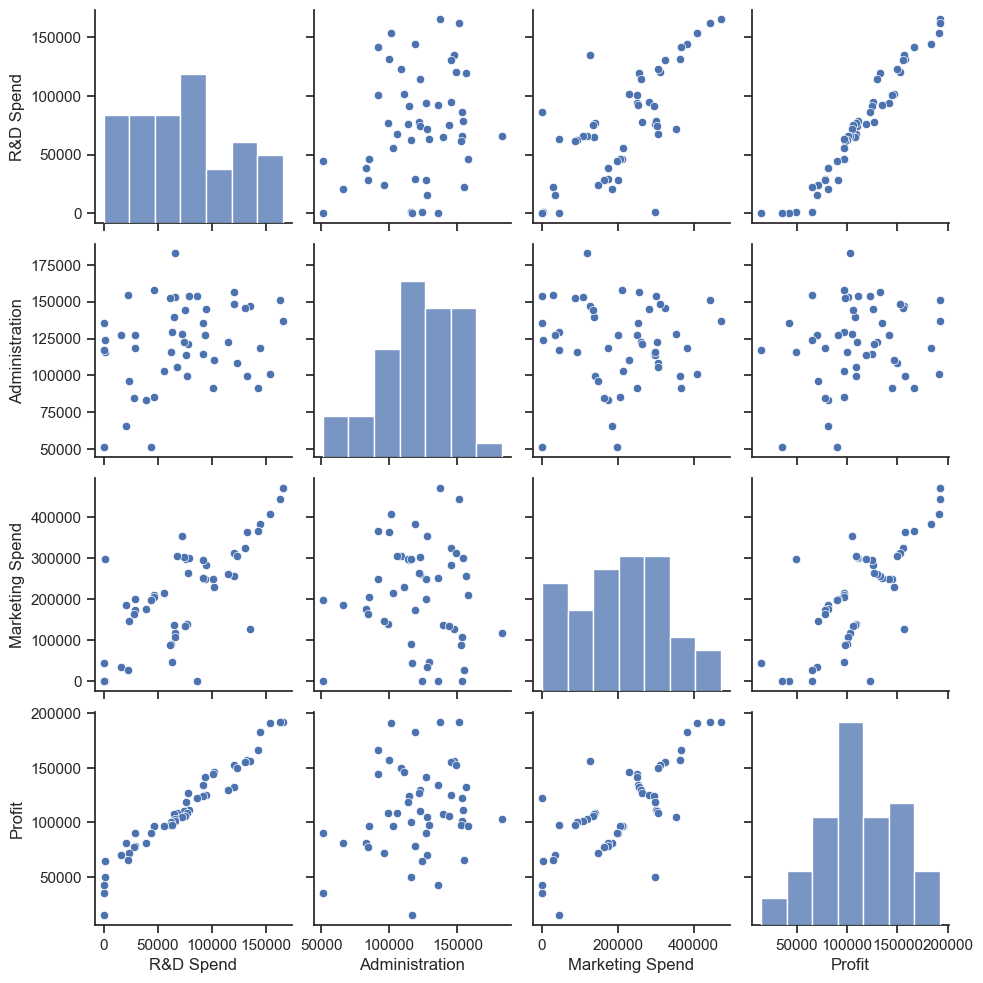

In [25]:
sns.pairplot(dataset)

# 12. Corrélations

#### Recall the covariance and the Pearson correlation coefficient
$$cov(x,y) = \frac{1}{n}\sum_{i=1}^n\left(x_i-mean_i\right)\left(y_j-mean_j\right), \quad pearson := \rho_{x,y} = \dfrac{cov(x,y)}{std_x std_y}$$

In [16]:
correlations = dataset.corr(method='pearson',numeric_only=True)

<Axes: >

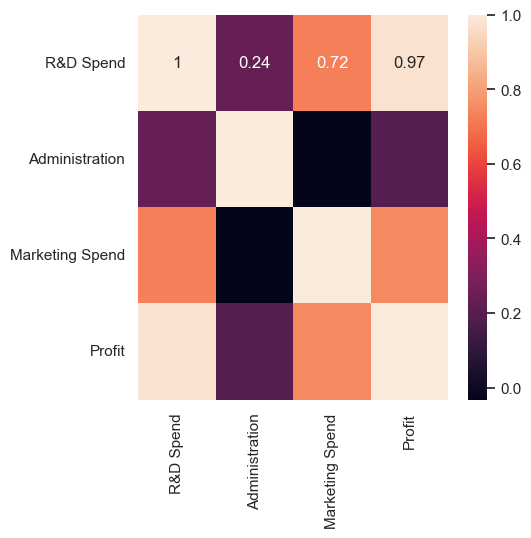

In [17]:
f, ax = plt.subplots(figsize = (5, 5))
sns.heatmap(correlations, annot = True)

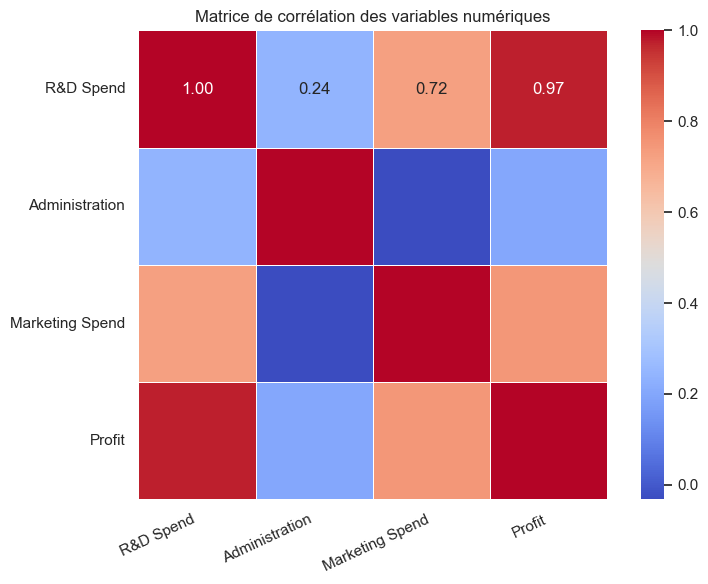

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

correlations = dataset.corr(method='pearson', numeric_only=True)

f, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    ax=ax
)

plt.title("Matrice de corrélation des variables numériques")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 13. Séparation entre variables explicatives et variable cible

In [28]:
# on sépare l'objectif des variables explicatives (features)
X = dataset.iloc[:,0:4].values # Extraction depuis un dataframe, extraction des 4 premières colonnes
#.iloc:Access group of rows and columns by integer position(s).
y = dataset.iloc[:,4].values
print(y)
print(X)
# .values sert à convertir de pandas vers numpy
type(X)

[192261.83 191792.06 191050.39 182901.99 166187.94 156991.12 156122.51
 155752.6  152211.77 149759.96 146121.95 144259.4  141585.52 134307.35
 132602.65 129917.04 126992.93 125370.37 124266.9  122776.86 118474.03
 111313.02 110352.25 108733.99 108552.04 107404.34 105733.54 105008.31
 103282.38 101004.64  99937.59  97483.56  97427.84  96778.92  96712.8
  96479.51  90708.19  89949.14  81229.06  81005.76  78239.91  77798.83
  71498.49  69758.98  65200.33  64926.08  49490.75  42559.73  35673.41
  14681.4 ]
[[165349.2 136897.8 471784.1 'New York']
 [162597.7 151377.59 443898.53 'California']
 [153441.51 101145.55 407934.54 'Florida']
 [144372.41 118671.85 383199.62 'New York']
 [142107.34 91391.77 366168.42 'Florida']
 [131876.9 99814.71 362861.36 'New York']
 [134615.46 147198.87 127716.82 'California']
 [130298.13 145530.06 323876.68 'Florida']
 [120542.52 148718.95 311613.29 'New York']
 [123334.88 108679.17 304981.62 'California']
 [101913.08 110594.11 229160.95 'Florida']
 [100671.96 9

numpy.ndarray

In [29]:
X.shape

(50, 4)

# 14. Encodage de la variable qualitative

In [30]:
# Prob2: Comment convertir une variable qualitative en une variable quantitative.
# Première méthode : LabelEncoder 
from sklearn.preprocessing import LabelEncoder
labelencoder_X = LabelEncoder() #creation de l'objet Labelencoder_X de la classe LabelEncoder()
# LabelEncoder() : Constructeur de la classe LabelEncoder
X[:,3] = labelencoder_X.fit_transform(X[:,3]) # mise à jour de la colonne d'ind 3 (state)
X[0:5,:]

array([[165349.2, 136897.8, 471784.1, 2],
       [162597.7, 151377.59, 443898.53, 0],
       [153441.51, 101145.55, 407934.54, 1],
       [144372.41, 118671.85, 383199.62, 2],
       [142107.34, 91391.77, 366168.42, 1]], dtype=object)

In [31]:
#deuxiéme méthode : onehotencoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer #importation de l'outil columntransformer
ct = ColumnTransformer([("State", OneHotEncoder(), [3])], remainder = 'passthrough') # creation de l'objet ct de classe columntransformer
X = ct.fit_transform(X)
X = X.astype('float64')
X.shape

(50, 6)

In [32]:
X[0:5,:]

array([[0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.6534920e+05,
        1.3689780e+05, 4.7178410e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.6259770e+05,
        1.5137759e+05, 4.4389853e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.5344151e+05,
        1.0114555e+05, 4.0793454e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.4437241e+05,
        1.1867185e+05, 3.8319962e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.4210734e+05,
        9.1391770e+04, 3.6616842e+05]])

In [33]:
# Avoid the trap of the Dummy variable
if X.shape[1]==6:
    X = X[:,1:]
X.shape

(50, 5)

# 15. Séparation apprentissage / test

In [34]:
# probleme 3 : création des données d'entrainement et des données d'évaluation 
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split # importation de l'outil 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)
X_train.shape ####################################################################################################ù

(40, 5)

# 16. Modèle KNN

In [35]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error,r2_score
from math import sqrt
import matplotlib.pyplot as plt
%matplotlib inline

In [36]:
reg = KNeighborsRegressor(n_neighbors=3)
reg.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [37]:
rmse_val = [] #to store rmse values for different k
for K in range(20):
    K = K+1
    model = KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train, y_train)  #fit the model
    pred=model.predict(X_test)   #make prediction on test set
    error = sqrt(mean_squared_error(y_test,pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    rsquared=r2_score(y_test,pred)
    print('RMSE value for k=' , K , 'is:', error)
    print('R2 value for k=' , K , 'is:', rsquared)

RMSE value for k= 1 is: 6964.372023424658
R2 value for k= 1 is: 0.9620745980769433
RMSE value for k= 2 is: 8441.32873968267
R2 value for k= 2 is: 0.9442829781028822
RMSE value for k= 3 is: 7907.414355801014
R2 value for k= 3 is: 0.9511082861624712
RMSE value for k= 4 is: 7730.953514111969
R2 value for k= 4 is: 0.9532660605759286
RMSE value for k= 5 is: 11973.251490143877
R2 value for k= 5 is: 0.8879039067653898
RMSE value for k= 6 is: 14320.107086947013
R2 value for k= 6 is: 0.8396537532160195
RMSE value for k= 7 is: 16464.015008298687
R2 value for k= 7 is: 0.7880478754598934
RMSE value for k= 8 is: 18614.274358857616
R2 value for k= 8 is: 0.7290691315804205
RMSE value for k= 9 is: 19514.83063579677
R2 value for k= 9 is: 0.7022197840478615
RMSE value for k= 10 is: 21319.63970403991
R2 value for k= 10 is: 0.6445929900573052
RMSE value for k= 11 is: 22580.119488476095
R2 value for k= 11 is: 0.6013252421836591
RMSE value for k= 12 is: 22412.227570495095
R2 value for k= 12 is: 0.6072318033

<Axes: >

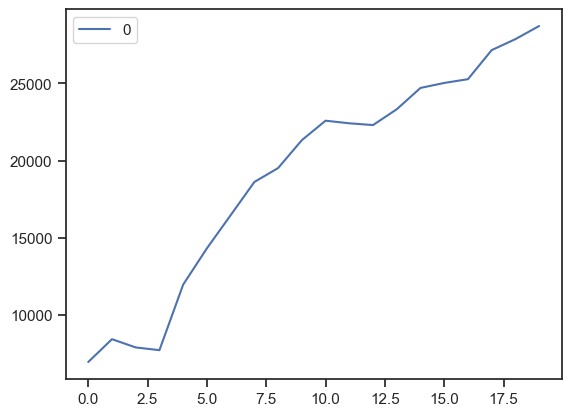

In [38]:
#plotting the rmse values against k values
curve = pd.DataFrame(rmse_val) #elbow curve 
curve.plot()

In [40]:
best_k = rmse_val.index(min(rmse_val)) + 1
best_rmse = min(rmse_val)

print("Meilleur nombre de voisins :", best_k)
print("RMSE minimale :", best_rmse)

Meilleur nombre de voisins : 1
RMSE minimale : 6964.372023424658


# 17. Standardisation des variables

In [41]:
#comment standardiser les variables(methodes) 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [42]:
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [43]:
X_train[0,:]

array([1.0000000e+00, 0.0000000e+00, 5.5493950e+04, 1.0305749e+05,
       2.1463481e+05])

In [44]:
X_train_sc[0,:]

array([ 1.73205081, -0.73379939, -0.35006454, -0.78547109,  0.1011968 ])

In [45]:
(667 - X_train[:,2].mean())/(X_train[:,2].std())

-1.5370573654984665

In [46]:
scaler.inverse_transform(X_train_sc[0:1,:])

array([[1.0000000e+00, 0.0000000e+00, 5.5493950e+04, 1.0305749e+05,
        2.1463481e+05]])

In [47]:
from sklearn.neighbors import KNeighborsRegressor #regressor
reg = KNeighborsRegressor(n_neighbors = 1)

In [48]:
reg.fit(X_train_sc,y_train) 

KNeighborsRegressor(n_neighbors=1)

In [49]:
y_pred_knn = reg.predict(X_test_sc)

In [50]:
for i in range(10):
    print(y_test[i], y_pred_knn[i])

103282.38 105733.54
144259.4 149759.96
146121.95 124266.9
77798.83 96778.92
191050.39 124266.9
105008.31 125370.37
81229.06 96479.51
97483.56 101004.64
110352.25 124266.9
166187.94 124266.9


In [51]:
rsquared2=r2_score(y_pred_knn,y_test)

In [53]:
from sklearn import neighbors
rmse_val = [] #to store rmse values for different k
for K in range(20):
    K = K+1
    model = neighbors.KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train_sc, y_train)  #fit the model
    pred=model.predict(X_test_sc) #make prediction on test set
    error = sqrt(mean_squared_error(y_test,pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    rsquared=r2_score(y_test,pred)
    print('RMSE value for k= ' , K , 'is:', error)
    print('R2 value for k= ' , K , 'is:', rsquared)

RMSE value for k=  1 is: 28186.458992690983
R2 value for k=  1 is: 0.3787773139699293
RMSE value for k=  2 is: 26740.544418175232
R2 value for k=  2 is: 0.44087777283662255
RMSE value for k=  3 is: 26869.24664139991
R2 value for k=  3 is: 0.43548271094574253
RMSE value for k=  4 is: 27059.199534787535
R2 value for k=  4 is: 0.4274727557289669
RMSE value for k=  5 is: 27872.79916106284
R2 value for k=  5 is: 0.39252635850967443
RMSE value for k=  6 is: 29385.8386071824
R2 value for k=  6 is: 0.32478443413671654
RMSE value for k=  7 is: 29911.909474089385
R2 value for k=  7 is: 0.30039236063383645
RMSE value for k=  8 is: 30124.23172822361
R2 value for k=  8 is: 0.29042512893152816
RMSE value for k=  9 is: 28566.855795852065
R2 value for k=  9 is: 0.3618964621194125
RMSE value for k=  10 is: 29547.289395642565
R2 value for k=  10 is: 0.31734455413864937
RMSE value for k=  11 is: 29509.938965284808
R2 value for k=  11 is: 0.3190693390282249
RMSE value for k=  12 is: 28306.615536799338
R2 

# 18. Modélisation

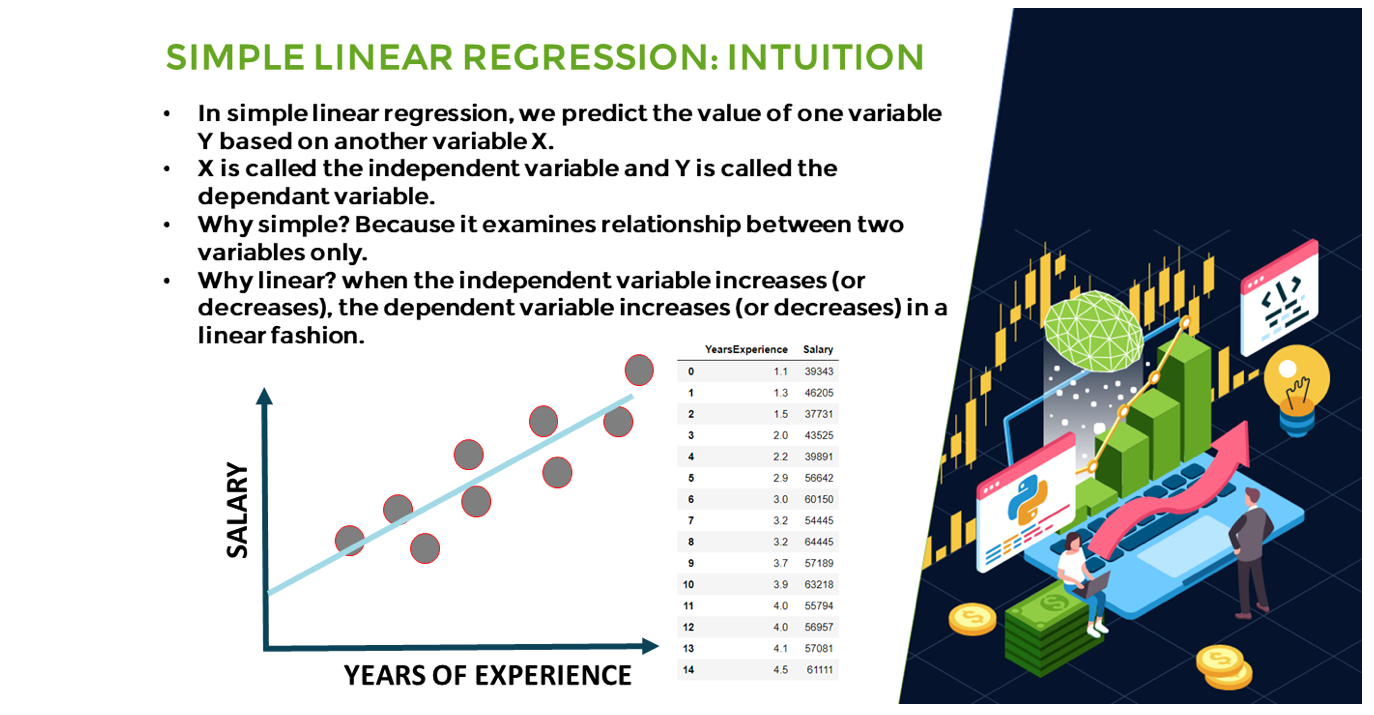

In [54]:
from IPython.display import display, Image
Image(filename='regression1.png')

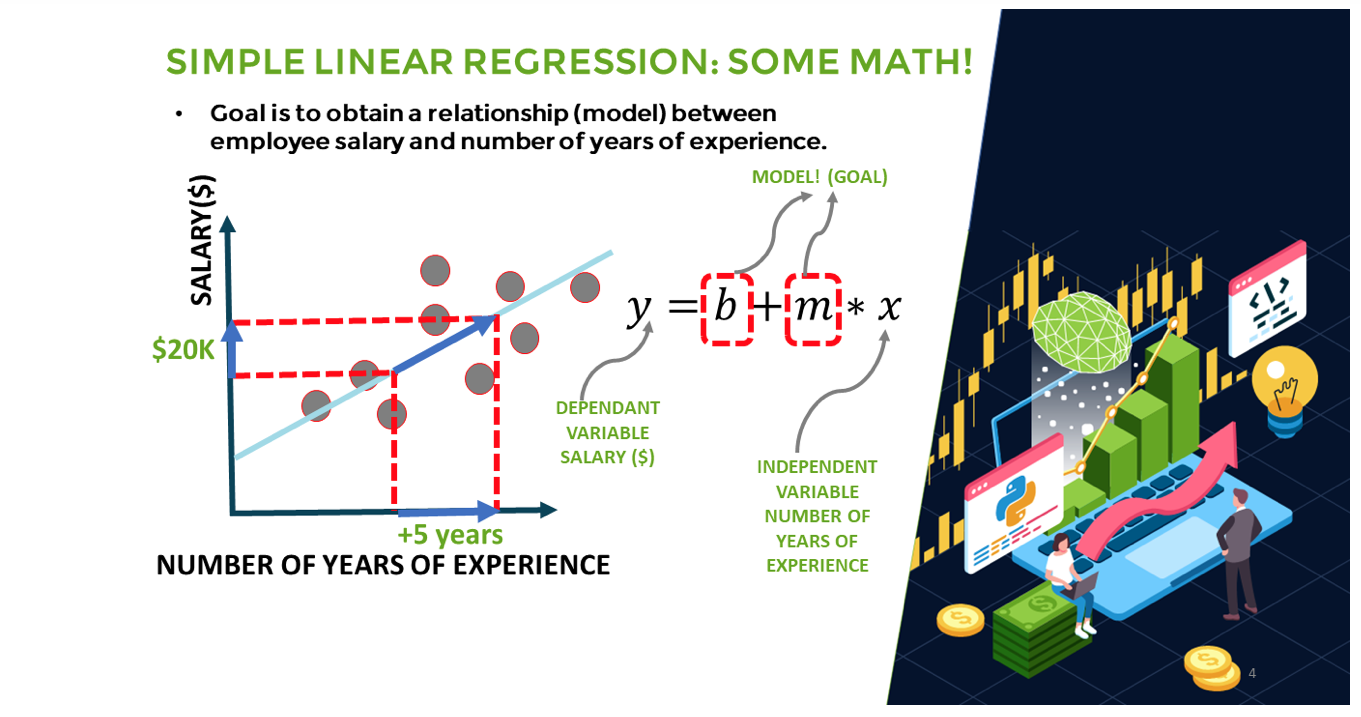

In [55]:
Image(filename='regression2.png')

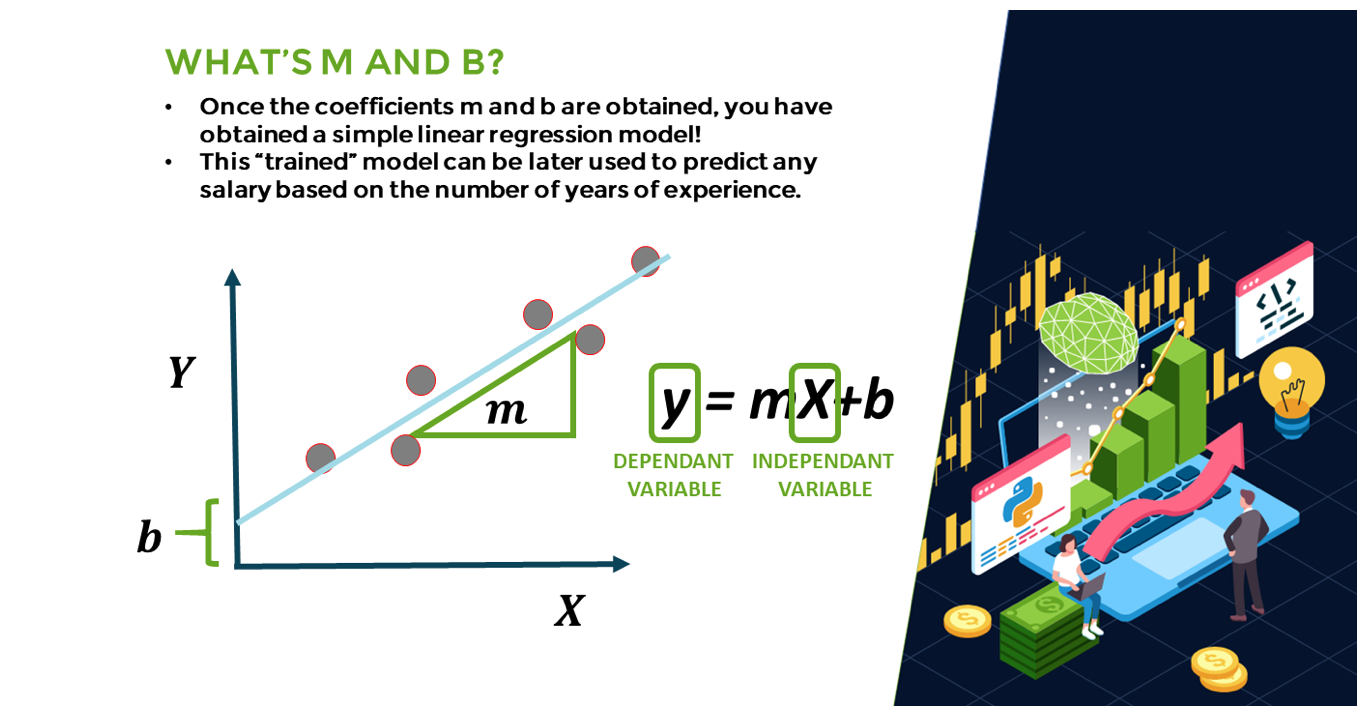

In [56]:
Image(filename='regression3.png')

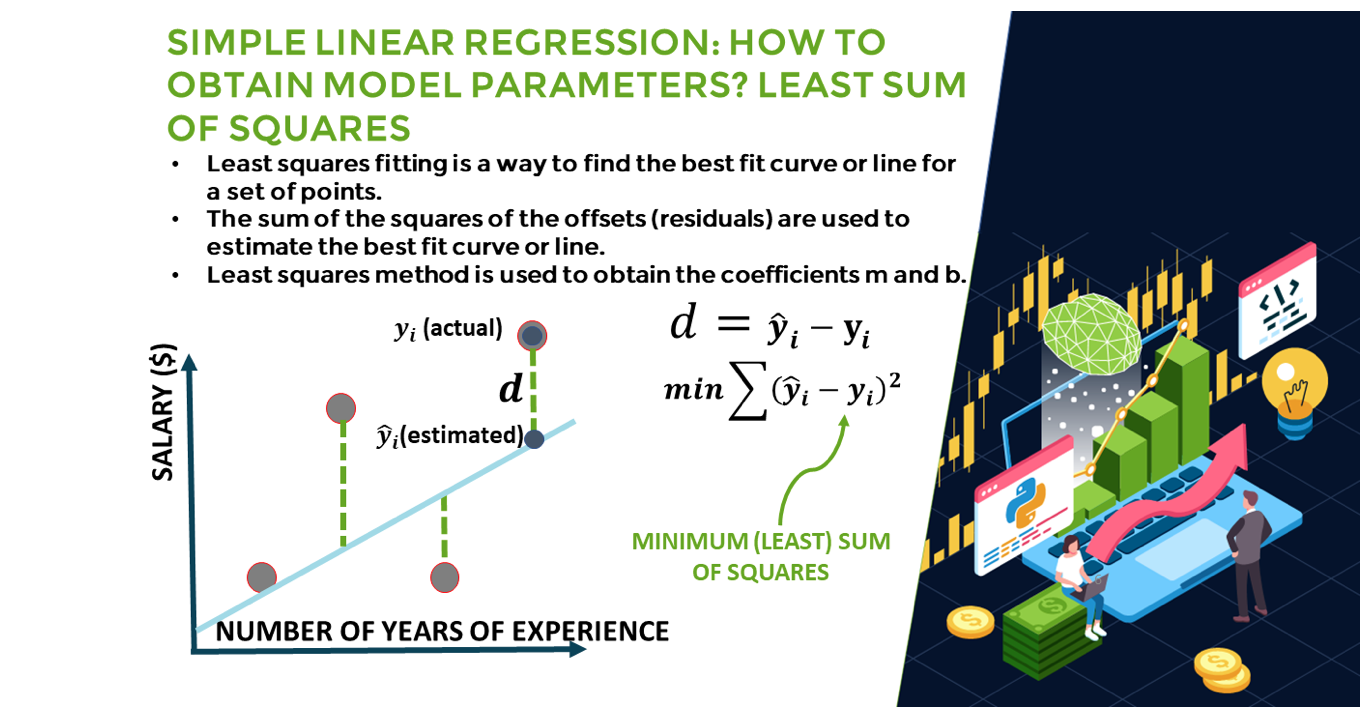

In [57]:
Image(filename='regression4.png')

In [58]:
from sklearn.linear_model import LinearRegression # importation de l'outil
regressor = LinearRegression() # on a crée l'objet
regressor.fit(X_train,y_train) # phase 1 : Entrainement
#input : X_train,y_train 
#output : les parametres 

LinearRegression()

In [59]:
print(f'b = {regressor.intercept_}')
print(f'm_i = {regressor.coef_}')

b = 42554.16761776614
m_i = [-9.59284160e+02  6.99369053e+02  7.73467193e-01  3.28845975e-02
  3.66100259e-02]


# 18. Prédiction et évaluation

In [60]:
# phase 2 : prédiction
y_pred = regressor.predict(X_test)
y_pred

array([103015.20159796, 132582.27760816, 132447.73845175,  71976.09851259,
       178537.48221054, 116161.24230163,  67851.69209676,  98791.73374688,
       113969.43533012, 167921.0656955 ])

In [61]:
# phase 3 : evaluation
for i in range(10):
    print([y_test[i],y_pred[i]])

[103282.38, 103015.20159796256]
[144259.4, 132582.27760815827]
[146121.95, 132447.73845174964]
[77798.83, 71976.09851258734]
[191050.39, 178537.4822105436]
[105008.31, 116161.24230163355]
[81229.06, 67851.69209676136]
[97483.56, 98791.73374687947]
[110352.25, 113969.43533011663]
[166187.94, 167921.065695502]


In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [63]:
def rmse(targets, predictions): 
    return np.sqrt(((predictions - targets) ** 2).mean())

In [64]:
print(f'MSE = {mean_squared_error(y_test, y_pred)}')
print(f'RMSE = {rmse(y_test, y_pred)}')
print(f'MAE = {mean_absolute_error(y_test, y_pred)}')
print(f'R2 = {r2_score(y_test,y_pred)}')

MSE = 83502864.03250822
RMSE = 9137.99015279116
MAE = 7514.293659636894
R2 = 0.9347068473282966


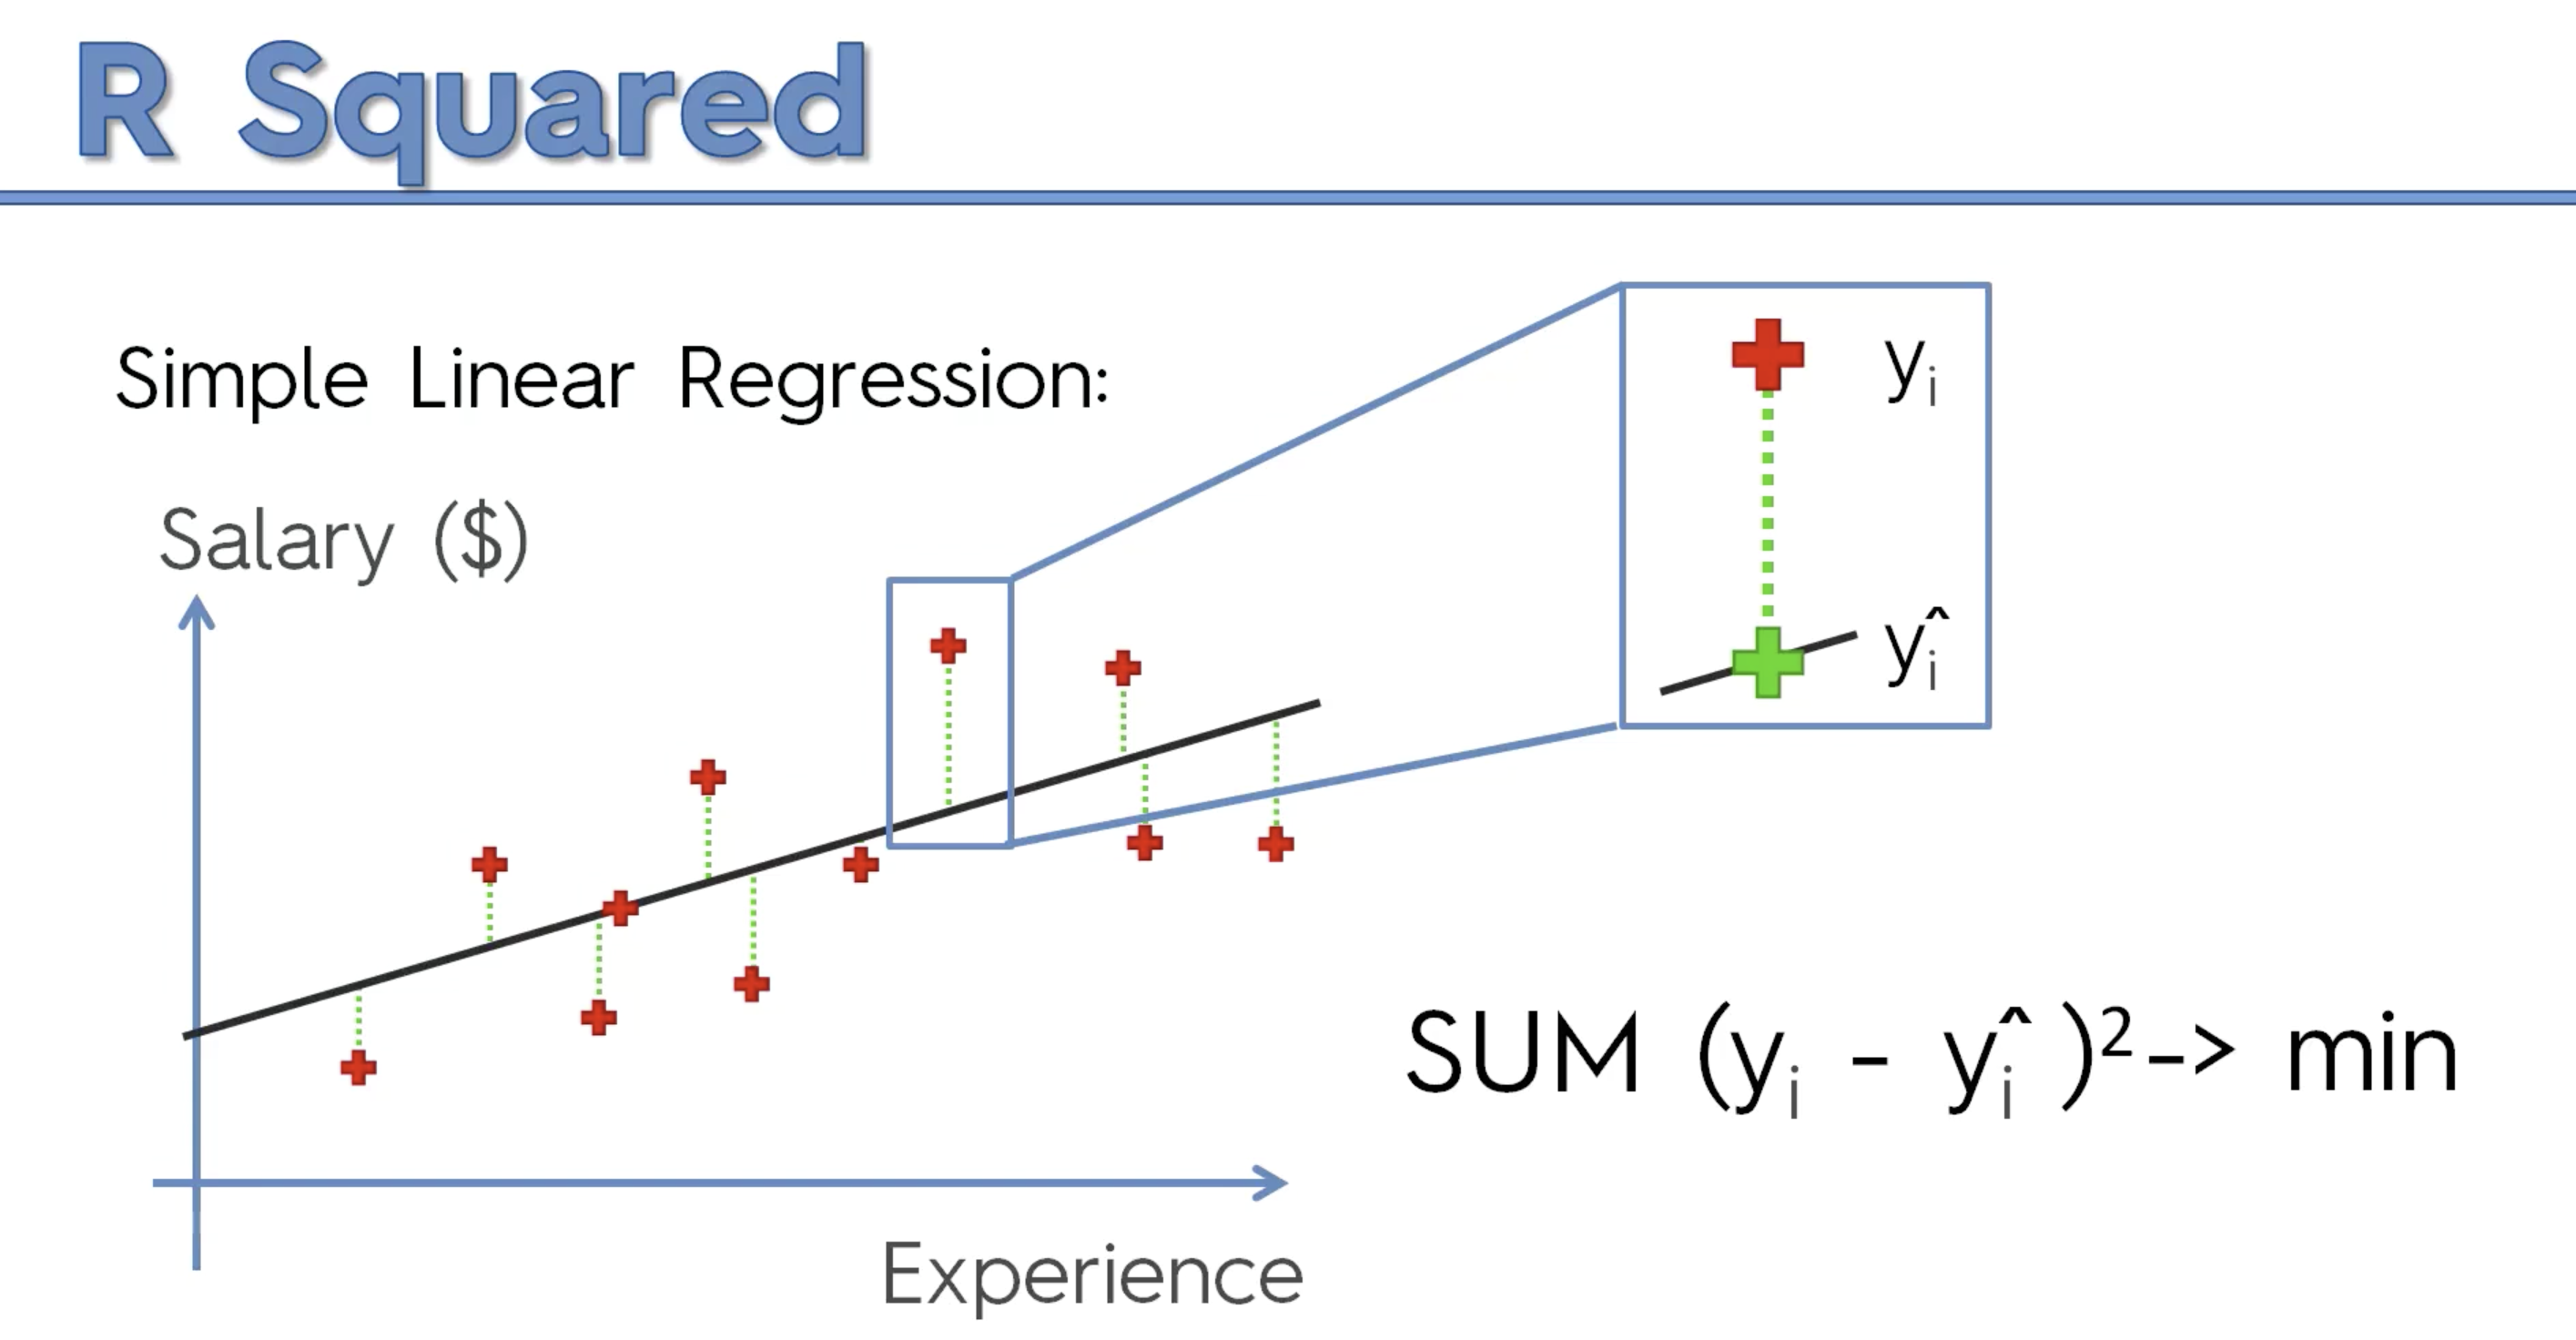

In [65]:
Image(filename='RSq1.png')

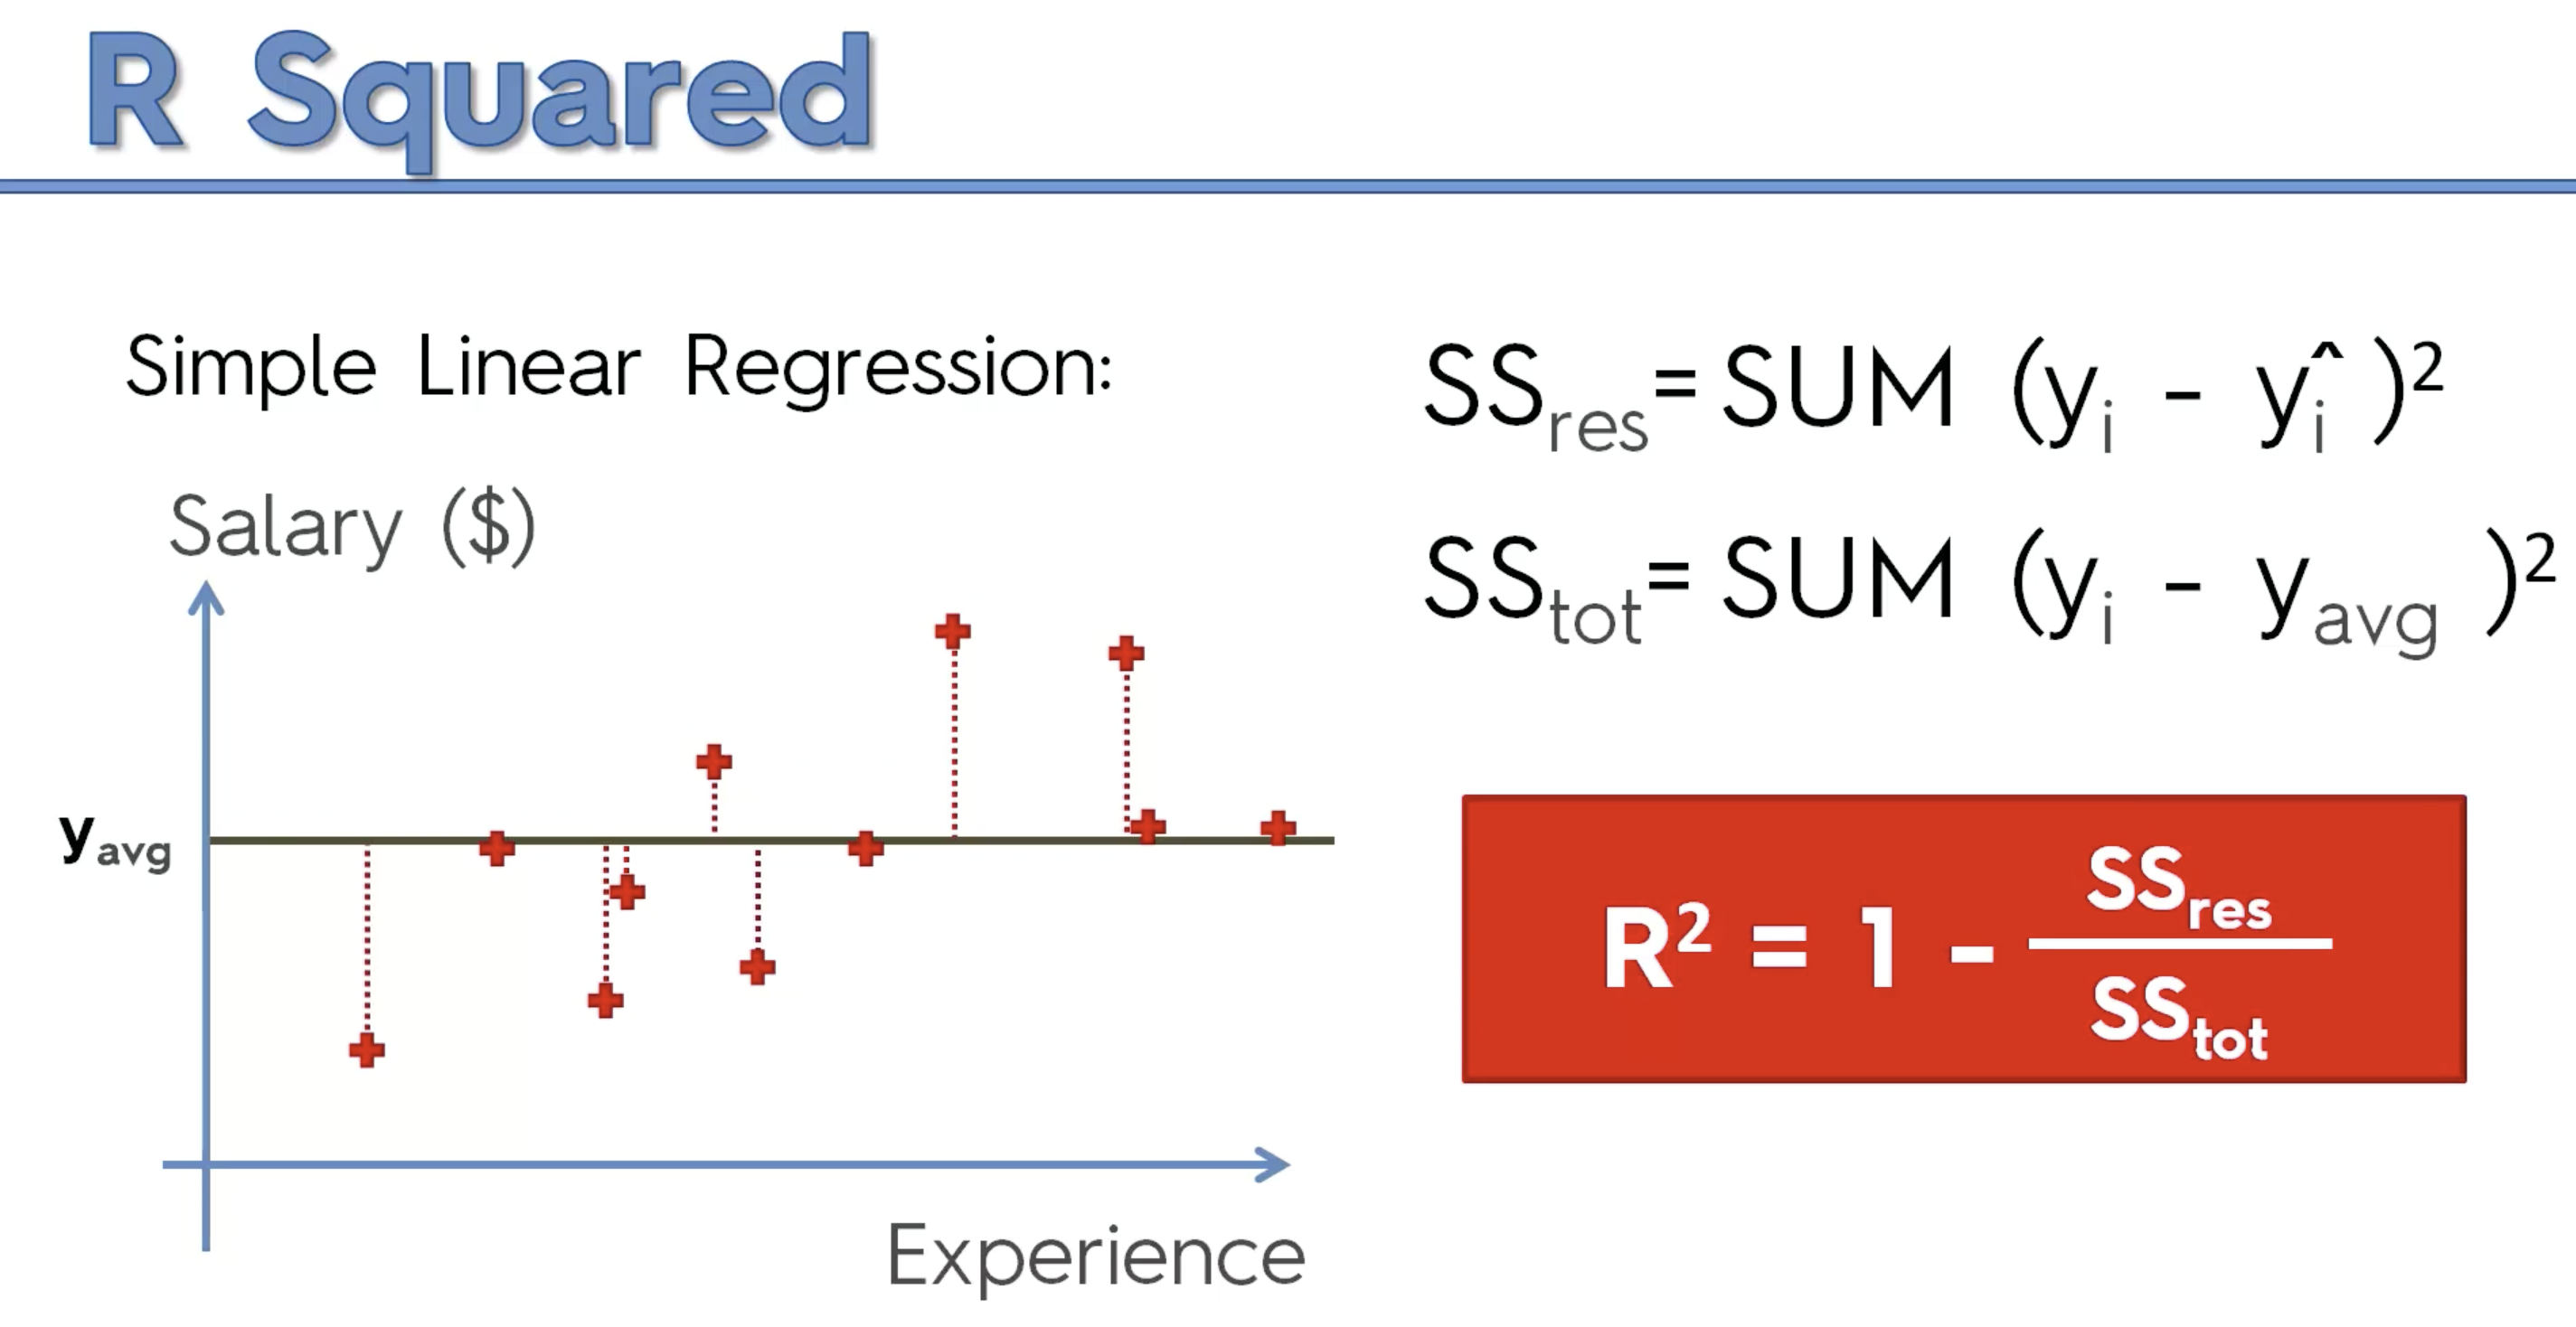

In [66]:
Image(filename='RSq2.png')